# Vector arithmetic
$$
\newcommand{\ket}[1]{|#1\rangle}
\newcommand{\bra}[1]{\langle#1|}
\newcommand{\norm}[1]{\left\lVert#1\right\rVert}
$$

In classical and quantum computation, there are certain operations on entire vectors that are ubiquitous. In this Jupyter notebook, we introduce three such vector arithmetic primitives for operating on vectors of Qubits:

- [`VectorAddition`](https://open-docs.construct.psiquantum.com/workbench_algorithms/reference/workbench_algorithms/subroutines/vector_arithmetic.html#workbench_algorithms.subroutines.vector_arithmetic.VectorAddition)
- [`OrthogonalDotProduct`](https://open-docs.construct.psiquantum.com/workbench_algorithms/reference/workbench_algorithms/subroutines/vector_arithmetic.html#workbench_algorithms.subroutines.vector_arithmetic.OrthogonalDotProduct)
- [`AbsoluteDisplacement`](https://open-docs.construct.psiquantum.com/workbench_algorithms/reference/workbench_algorithms/subroutines/vector_arithmetic.html#workbench_algorithms.subroutines.vector_arithmetic.AbsoluteDisplacement)

As their names suggest, these three primitives compute (1) the sum (or difference) of two vectors (component-wise), (2) the orthogonal dot product of a vector with itself (i.e. the square and sum of its components), and (3) the inverse absolute value difference of two vectors, respectively. 

Below, we dive into each of these Qubricks. For all of the examples below, we assume we have vectors where each component is a register of qubits. In particular, let's consider two vectors with 3 components each, $\vec{a} = \big[\ket{x_1}, \ket{y_1}, \ket{z_1}\big]$ and $\vec{b} = \big[\ket{x_2}, \ket{y_2}, \ket{z_2}\big]$. We will also be using the following (abuse of) notation as a shorthand: $\ket{\vec{a}} := \ket{x_1}\ket{y_1}\ket{z_1}$ and $\ket{\vec{b}} := \ket{x_2}\ket{y_2}\ket{z_2}$.

## A brief comment on backends plus airthmetic Qubricks used below

### Backends
For each circuit example below, we will be using Workbench filters. Even for small instance sizes, some of these circuits are incredibly large, and thus, we cannot execute a full state vector sim. However, since these Qubricks are only performing classical reversible logic, we can test these circuits using different backends which do not store state vectors. 
- The `">>bit-sim>>"` backend allows us to run classical logic (i.e. no superpositions).
- The `">>64bit>>"` filter allows us to run circuits on _more_ than 64 qubits.
- These filters are included in the `BIT_DEFAULT` filter preset.

### Arithmetic Qubricks
All of these Qubricks take arithmetic-based sub-Qubricks as arguments to their constructors. All of the sub-Qubricks passed in can be naïve arithmetic based, or Gidney arithmetic based. For the sake of this tutorial, we will be passing in Gidney-based arithmetic routines, though you could feel free to import naïve arithmetic Qubricks and pass those in instead.

## Adding and subtracting vectors

We very often would like to add or subtract two vectors from each other. The `VectorAddition` Qubrick (with different settings for addition and subtraction) performs the following transformation:

$$\ket{\vec{a}}\ket{\vec{b}}\big(\ket{0}\big) \rightarrow \ket{\vec{a}}\ket{\vec{b}}\big(\ket{x_1 \pm x_2}\ket{y_1 \pm y_2}\ket{z_1 \pm z_2}\big)$$

### How the circuit works (in words):

This one is quite straightforward. We loop through each qubit register in the list of registers, and we add (subtract) component-wise, allocating fresh qubits for each component-wise sum (difference). A simple tunable knob of `self.subtract_condition = True` allows us to switch from adding to subtracting vectors.

### Show me the code

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from psiqworkbench import Qubits, QInt, QPU
from psiqworkbench.filter_presets import BIT_DEFAULT
from psiqworkbench.qubricks import GidneySquare, GidneyAdd, RSqrt
from workbench_algorithms import OrthogonalDotProduct, AbsoluteDisplacement, VectorAddition
from psiqworkbench.utils.misc_utils import random_list_vals_n_bit_precision
from itertools import chain
import numpy as np

In [3]:
# generate two lists of values
bit_size = 3
num_components = 3
vals1 = [1, -2, 2]
vals2 = [1, 1, 0]

In [4]:
# set up total number of qubits
num_vec1 = bit_size * num_components
num_vec2 = bit_size * num_components
num_result_regs = num_vec1
num_gidney_anc = bit_size
num_qubits = num_vec1 + num_vec2 + num_result_regs + num_gidney_anc

In [5]:
# set up QPU and write values to each vector component
qc = QPU(filters=BIT_DEFAULT)
qc.reset(num_qubits)
q_vec1 = [QInt(bit_size, f'q_vec1_{i}', qc) for i in range(num_components)]
q_vec2 = [QInt(bit_size, f'q_vec2_{i}', qc) for i in range(num_components)]

for j, (reg1, reg2) in enumerate(zip(q_vec1, q_vec2)):
    reg1.write(vals1[j])
    reg2.write(vals2[j])

In [6]:
# set up Qubrick
adder = GidneyAdd(release_ancillae=True)
vec_add = VectorAddition(adder, subtract_condition=False)

In [7]:
# call the vector add
vec_add.compute(q_vec1, q_vec2)
result_qregs = vec_add.result_qregs

In [8]:
# compare circuit result and expected result
for i in range(len(result_qregs)):
    circuit_result = result_qregs[i].read()
    expected_result = vals1[i] + vals2[i]
    print("Circuit result", circuit_result)
    print("Expected result", expected_result)
    assert circuit_result == expected_result

Circuit result 2
Expected result 2
Circuit result -1
Expected result -1
Circuit result 2
Expected result 2


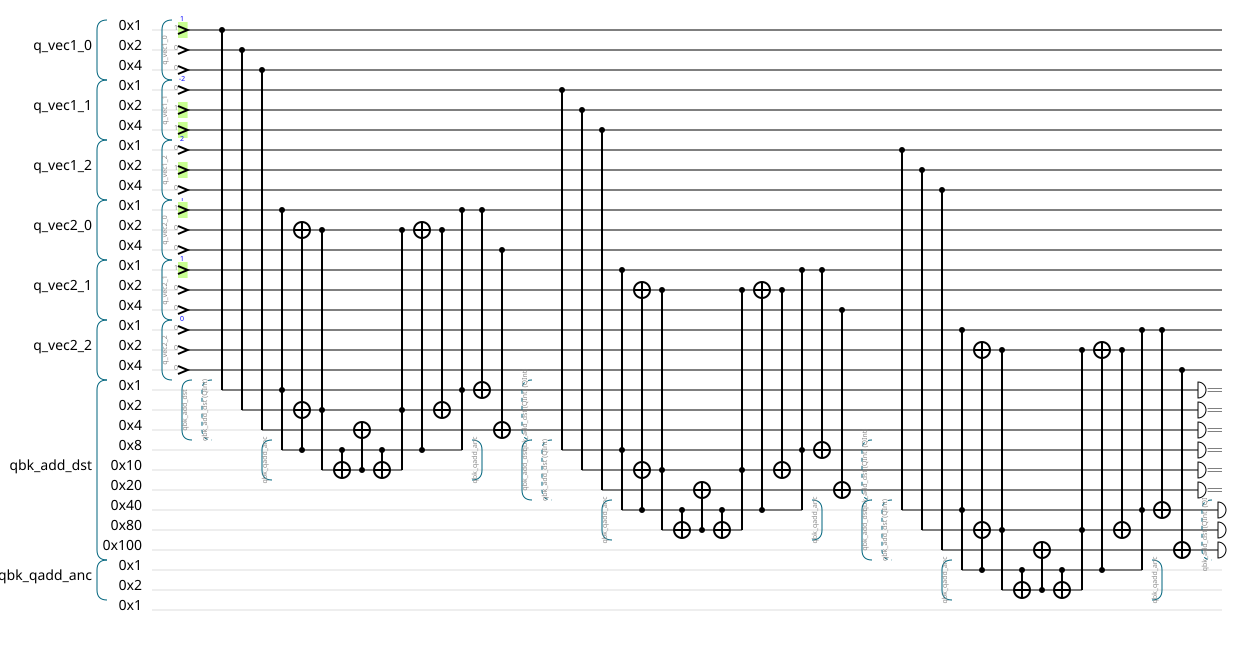

In [9]:
# draw the circuit
qc.draw()

**Some things to note**:
- The `VectorAddition` Qubrick takes in two args, an adder Qubrick, and a boolean indicating whether we are adding or subtracting.
- The `compute` only needs to take in two lists of Qubits.
- As input you have two lists of `num_components` many registers each, as output you have one list of `num_components` many registers (i.e. the sums or differences).
- The length of both lists must be equal (since you can only add or subtract vectors of the same dimension).
- To flip the above example to a subtractor, simpy change `subtract_condition` from `False` to `True`.
    - You may need to increase the bit size depending on the input values for both vectors since we are representing signed integers.
    - You would need to alter the `expected_result` to be a difference rather than a sum.
    - The order of the two vectors in `compute` _matters_ for subtraction!

## Squaring a vector of qubits

Suppose we have a vector of 3 components, $x$, $y$, and $z$. The `OrthogonalDotProduct` Qubrick performs the following transformation:

$$\ket{x}\ket{y}\ket{z}\ket{0} \rightarrow \ket{x}\ket{y}\ket{z}\ket{x^2 + y^2 + z^2}$$

The `OrthogonalDotProduct` Qubrick will do exactly this: given a list of vector components (such as $\big[\ket{x}, \ket{y}, \ket{z}\big]$), output their squared sum onto a new register of Qubits.

### How the circuit works (in words):

Each of the components is stored in a separate `Qubits` register. Each component is squared using your favorite squaring `Qubrick`, and the output of each of these squared components is dumped onto separate ancillary registers. Then, all of these squares are accumulated onto the squared ancillary register of the first component.

### Show me the code

In [10]:
# generate a random list of values
bit_size = 2
num_components = 2
vals = random_list_vals_n_bit_precision(bit_size, num_components)

In [11]:
# set up the total number of qubits (don't worry if this part is opaque)

# NOTE (Will): this number of qubits only works if `release_ancillae == True`
num_squared_qbits = num_components * 2 * bit_size
num_input_qbits = num_components * bit_size
num_overflow_add_bits = num_components - 1
num_anc_qbits = num_overflow_add_bits + 2 * bit_size - 1
num_qubits = num_squared_qbits + num_input_qbits + num_anc_qbits + num_overflow_add_bits

In [12]:
# set up QPU and write values to each vector component
qc = QPU(filters=BIT_DEFAULT)
qc.reset(num_qubits)
qregs = [Qubits(bit_size, f'comp_{i}', qc) for i in range(num_components)]

for i, qreg in enumerate(qregs):
    qreg.write(vals[i])

In [13]:
# set up sub-Qubricks
square = GidneySquare(release_ancillae=False, allow_negative_input=False)
add = GidneyAdd(release_ancillae=False)

In [14]:
# calculate the square of the particle register
odp = OrthogonalDotProduct(square=square, add=add, release_ancillae=True)
odp.compute(qregs)
result = odp.get_result_qreg()

In [15]:
# compare the calculated result and the expected result
circuit_result = result.read()
expected_result = sum([val**2 for val in vals])
print("Result", circuit_result)
print("Expected result", expected_result)
assert circuit_result == expected_result

Result 10
Expected result 10


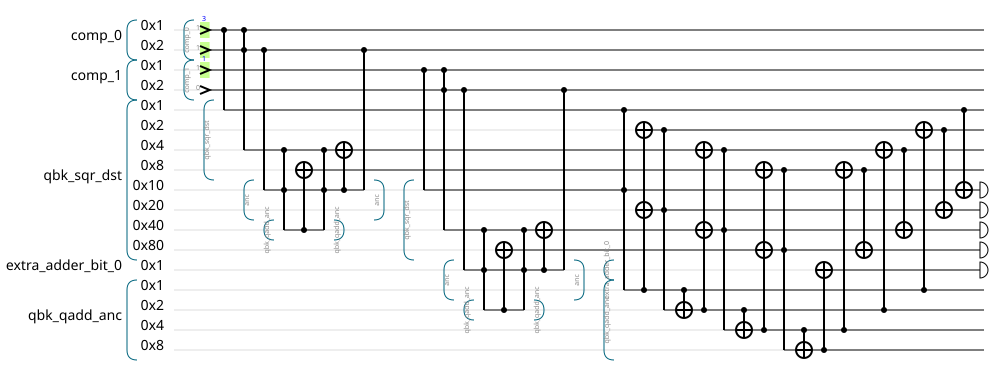

In [16]:
# print the circuit
qc.draw()

**Some notes on the above**:
- For the above example, we start by generating a random list of `num_component` many values, and then we write those values onto `num_component` many different registers.
- This Qubrick works for _any_ number of components `num_component`, and _any_ number of bits of precision `bit_size` per component.
- The `OrthogonalDotProduct` Qubrick takes two sub-Qubricks:
    - A squaring Qubrick to square each component individually.
    - An adder Qubrick to sum up all of those squares.
- `OrthogonalDotProduct` takes one argument in its `compute` method: the list of vector components (where each component is a `Qubits` object).

## Computing the absolute displacement of two vectors of qubits

Suppose we have two vectors, each of 3 components: $\vec{a} = \big[\ket{x_1}, \ket{y_1}, \ket{z_1}\big]$ and $\vec{b} = \big[\ket{x_2}, \ket{y_2}, \ket{z_2}\big]$. The `AbsoluteDisplacment` Qubrick does the following:

$$\big(\ket{x_1}\ket{y_1}\ket{z_1}\big)\big(\ket{x_2}\ket{y_2}\ket{z_2}\big)\ket{0} := \ket{\vec{a}}\ket{\vec{b}}\ket{0} \rightarrow \ket{\vec{a}}\ket{\vec{b}}\ket{1/\lvert \vec{a} - \vec{b} \rvert}$$

where:

$$\lvert \vec{a} - \vec{b} \rvert= \sqrt{(x_1-x_2)^2 + (y_1-y_2)^2 + (z_1-z_2)^2}$$

### How the circuit works (in words):

The circuit steps follow logically from the expression above. We need to:
- First compute the difference component by component for both vectors, i.e. do $\ket{x_1}\ket{x_2}\ket{0} \rightarrow \ket{x_1}\ket{x_2}\ket{x_1 - x2}$ (we can do this using the `VectorAddition` Qubrick introduced earlier).
- We then square the resulting difference vectors and dump those into another ancillary register (i.e. do $\ket{x_1 - x2}\ket{0} \rightarrow \ket{x_1 - x2}\ket{(x_1 - x_2)^2}$), and then add them all up together (both of these steps are just using the `OrthogonalDotProduct` Qubrick introduced above).
- Finally, we take the inverse square root of the resulting output register by using a Qubrick designed for this.

### Show me the code

In [17]:
# set up some initial component values for both vectors
# in this example, both vectors will have two components
vec1_vals = (1, 2)
vec2_vals = (-3, 2)

In [18]:
# set up a number of qubits
max_position_val = max(np.abs(list(chain.from_iterable([vec1_vals] + [vec2_vals]))))
bit_size = 2 * int(np.ceil(np.log2(max_position_val))) + 1  # double to handle signed QInts

In [19]:
# set up QPU and write values to each vector component
qc = QPU(filters=BIT_DEFAULT)
qc.reset(86)

q_vec1 = [QInt(bit_size, 'r_reg1_{0}'.format(i), qc) for i in range(len(vec1_vals))]
q_vec2 = [QInt(bit_size, 'r_reg2_{0}'.format(i), qc) for i in range(len(vec2_vals))]

for j, (reg1, reg2) in enumerate(zip(q_vec1, q_vec2)):
    reg1.write(vec1_vals[j])
    reg2.write(vec2_vals[j])

In [20]:
# set up sub-Qubricks
square = GidneySquare(release_ancillae=False, allow_negative_input=True)
add = GidneyAdd(release_ancillae=False)
dot_product = OrthogonalDotProduct(square=square, add=add, release_ancillae=False)

subtract = GidneyAdd(release_ancillae=False)
vec_sub = VectorAddition(subtract, subtract_condition=True)
rsqrt = RSqrt()

In [21]:
# set up the main Qubrick
abs_disp = AbsoluteDisplacement(dot_product, vec_sub, rsqrt)

# calculate the absolute displacement
abs_disp.compute(q_vec1, q_vec2)
result = abs_disp.get_result_qreg()

circuit_result = result.read()

In [22]:
# compare the calculated result and the expected result
res = np.array(vec1_vals) - np.array(vec2_vals)
res = np.sum(res**2)
res = 1 / np.sqrt(res)
expected_result = res
print("Result", circuit_result)
print("Expected result", expected_result)
assert np.abs(circuit_result - expected_result) <= 0.05

Result 0.2412109375
Expected result 0.25


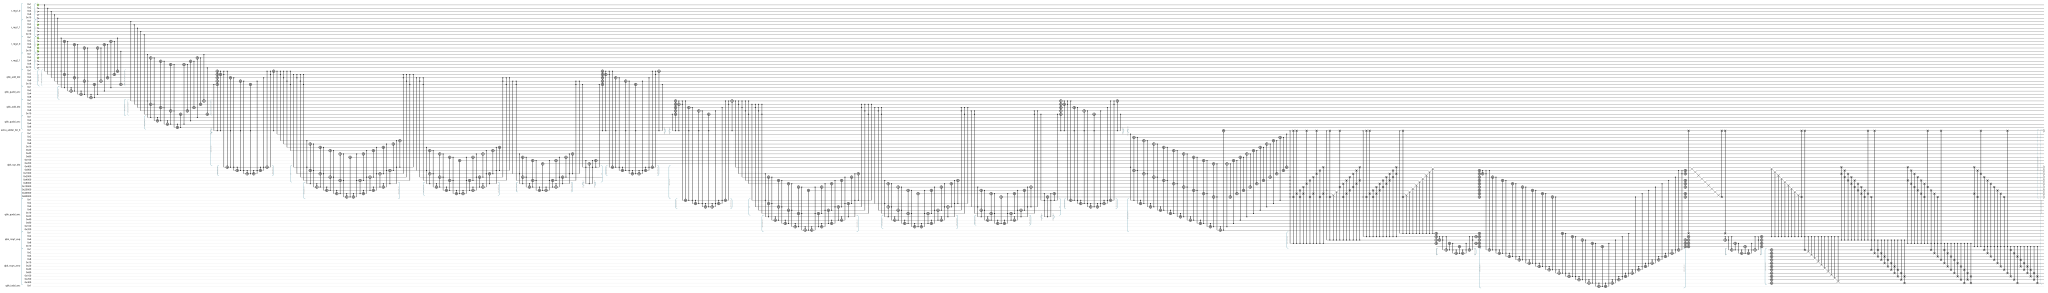

In [23]:
# print the circuit
qc.draw()

**Some (many) things to note:**
- We can handle negative or positive values for the components of each vector.
- We can handle any number of components for the two vectors.
- The number of components of both vectors needs to be equal in this implementation.
- There are many sub-Qubricks used here, and they run a few levels deep. They are:
    - Squaring Qubricks and addition Qubricks for use in `OrthogonalDotProduct`.
    - Addition Qubrick for use in `VectorAddition` (with `subtract_condition` set to `True`).
    - The inverse-square-root Qubrick, `OrthogonalDotProduct` Qubrick, and `VectorAddition` Qubrick for use in `AbsoluteDisplacement`
- The `compute` method for `AbsoluteDisplacement` takes both of the lists of Qubits representing the two vectors.
    - It also takes an optional argument (not shown here) for the precision of the inverse-square-root. This is a boolean value which sets `True` for high precision, and `False` for low precision. We comment on this choice in the last subsection.
- You will notice we allocated 68 qubits for this bit simulation. The exact expression for the number of qubits necessary as a function of the inputs is difficult to determine. If you decide to alter the code cells to input larger instance sizes (either larger values which require more bits to represent, or more components per vector), you will need to continue to increase the number of total qubits until the code can run.

## A couple of asides on the use of `RSqrt`

One of the steps in this algorithm is to take the inverse-square-root of a register of Qubits. As of today, we have exactly _one_ implementation of a circuit for this: `RSqrt`. You may notice in the example above where we compare the circuit value and the expected value, we do not assert that they must be equal, but rather, that they must be within `0.05` of each other. This is a nontrivial feature of the use of `RSqrt`. This is because, unfortunately, the exact difference between the expected and calculated value for $\frac{1}{x}$ _depends_ on the value of $x$.

Additionally, as mentioned above, there is an optional `high_precision` argument to pass to the `compute` method of `AsboluteDisplacement`, which gets passed down to `RSqrt` internally. This determines how many additional qubits to use to represent the final output inverse-square-root. The low and high precision versions do not vary substantially for _all_ input values; understanding this difference is a work-in-progress, and will be the subject of future tutorials.